<a href="https://colab.research.google.com/github/arcctg/kpi-ml-lab6/blob/main/01_applicant_admission_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applicant Admission Prediction

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## 1. Data Generation

In [126]:
def generate_applicant_data(n=2000, seed=42):
    np.random.seed(seed)
    
    PRIVILEGED_RATIO = 0.13
    N_ANOMALIES = 100
    
    math_scores = np.clip(np.random.normal(155, 20, n), 100, 200).astype(int)
    english_scores = np.clip(np.random.normal(155, 20, n), 100, 200).astype(int)
    ukrainian_scores = np.clip(np.random.normal(155, 20, n), 100, 200).astype(int)
    
    privileged = np.zeros(n, dtype=int)
    privileged_indices = np.random.choice(n, size=int(n * PRIVILEGED_RATIO), replace=False)
    privileged[privileged_indices] = 1
    
    anomaly_indices = np.random.choice(n, size=N_ANOMALIES, replace=False)
    for i, idx in enumerate(anomaly_indices):
        anomaly_type = i % 8
        if anomaly_type == 0:
            math_scores[idx] = np.random.randint(100, 115)
            english_scores[idx] = np.random.randint(100, 115)
            ukrainian_scores[idx] = np.random.randint(100, 115)
        elif anomaly_type == 1:
            math_scores[idx] = np.random.randint(190, 201)
            english_scores[idx] = np.random.randint(180, 201)
            ukrainian_scores[idx] = np.random.randint(100, 115)
        elif anomaly_type == 2:
            math_scores[idx] = np.random.randint(100, 130)
            english_scores[idx] = np.random.randint(190, 201)
            ukrainian_scores[idx] = np.random.randint(170, 201)
        elif anomaly_type == 3:
            math_scores[idx] = np.random.randint(180, 201)
            english_scores[idx] = np.random.randint(100, 115)
            ukrainian_scores[idx] = np.random.randint(180, 201)
        elif anomaly_type == 4:
            math_scores[idx] = 200
            english_scores[idx] = 200
            ukrainian_scores[idx] = 200
        elif anomaly_type == 5:
            math_scores[idx] = 200
            english_scores[idx] = 200
            ukrainian_scores[idx] = 100
        elif anomaly_type == 6:
            math_scores[idx] = 100
            english_scores[idx] = 200
            ukrainian_scores[idx] = 200
        elif anomaly_type == 7:
            math_scores[idx] = 200
            english_scores[idx] = 100
            ukrainian_scores[idx] = 200
            
    rating = 0.4 * math_scores + 0.3 * english_scores + 0.3 * ukrainian_scores
    
    return pd.DataFrame({
        'id': range(1, n + 1),
        'math': math_scores,
        'english': english_scores,
        'ukrainian': ukrainian_scores,
        'privileged': privileged,
        'rating': rating
    })

df = generate_applicant_data(n=2000, seed=42)
df_current = generate_applicant_data(n=2000, seed=123)

print("Generated Historical Dataset (Train/Test):", len(df), "applicants")
print("Generated Current Year Dataset (Inference):", len(df_current), "applicants")

Generated Historical Dataset (Train/Test): 2000 applicants
Generated Current Year Dataset (Inference): 2000 applicants


In [127]:
def determine_admission(data, total_seats=350, privileged_quota=35):
    admitted = np.zeros(len(data), dtype=int)

    priv_mask = data['privileged'] == 1
    non_priv_mask = data['privileged'] == 0

    priv_eligible = data[priv_mask & 
                       (data['math'] >= 120) & 
                       (data['english'] >= 120) & 
                       (data['ukrainian'] >= 120) & 
                       (data['rating'] >= 144)].copy()

    non_priv_eligible = data[non_priv_mask & 
                           (data['math'] >= 140) & 
                           (data['english'] >= 120) & 
                           (data['ukrainian'] >= 120) & 
                           (data['rating'] >= 160)].copy()

    priv_eligible = priv_eligible.sort_values('rating', ascending=False)
    non_priv_eligible = non_priv_eligible.sort_values('rating', ascending=False)

    priv_admitted = priv_eligible.head(privileged_quota)
    n_priv_admitted = len(priv_admitted)

    remaining_seats = total_seats - n_priv_admitted
    non_priv_admitted = non_priv_eligible.head(remaining_seats)

    admitted_indices = list(priv_admitted.index) + list(non_priv_admitted.index)
    admitted[admitted_indices] = 1

    return admitted

df['admitted'] = determine_admission(df)

df_current['admitted'] = determine_admission(df_current)

os.makedirs('data', exist_ok=True)
df.to_csv('data/applicants_historical.csv', index=False)
df_current.to_csv('data/applicants_current_year.csv', index=False)

print(f"Historical Dataset shape: {df.shape}")
print(f"Historical Admitted: {df['admitted'].sum()}")
print(f"Current Year Dataset shape: {df_current.shape}")
print(f"Current Year Admitted: {df_current['admitted'].sum()}")

Historical Dataset shape: (2000, 7)
Historical Admitted: 350
Current Year Dataset shape: (2000, 7)
Current Year Admitted: 350


## 2. Exploratory Data Analysis

In [128]:
df.head(10)

,id,math,english,ukrainian,privileged,rating,admitted
0,1,164,141,137,0,149.0,0
1,2,152,152,154,0,152.6,0
2,3,167,139,155,1,155.0,0
3,4,185,148,164,0,167.6,1
4,5,200,200,100,0,170.0,0
5,6,150,159,166,0,157.5,0
6,7,186,155,100,0,150.9,0
7,8,170,138,142,0,152.0,0
8,9,145,168,145,1,151.9,0
9,10,165,173,167,0,168.0,1


In [129]:
df.describe()

,id,math,english,ukrainian,privileged,rating,admitted
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,155.801500,154.661500,153.920000,0.130000,154.89505,0.175000
std,577.494589,21.624128,21.661868,21.675666,0.336388,12.55803,0.380062
min,1.000000,100.000000,100.000000,100.000000,0.000000,103.30000,0.000000
25%,500.750000,142.000000,140.000000,140.000000,0.000000,146.70000,0.000000
50%,1000.500000,156.000000,155.000000,154.000000,0.000000,155.10000,0.000000
75%,1500.250000,170.000000,169.000000,168.000000,0.000000,163.40000,0.000000
max,2000.000000,200.000000,200.000000,200.000000,1.000000,200.00000,1.000000


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          2000 non-null   int64  
 1   math        2000 non-null   int64  
 2   english     2000 non-null   int64  
 3   ukrainian   2000 non-null   int64  
 4   privileged  2000 non-null   int64  
 5   rating      2000 non-null   float64
 6   admitted    2000 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 109.5 KB


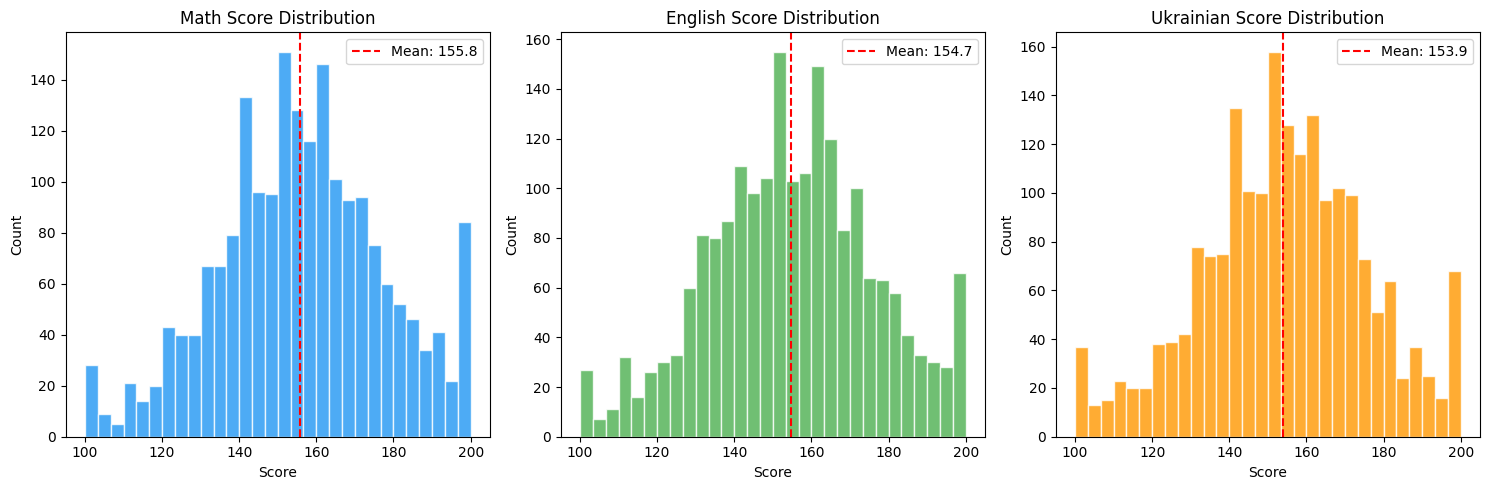

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, ['math', 'english', 'ukrainian'],
                           ['#2196F3', '#4CAF50', '#FF9800']):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(f'{col.capitalize()} Score Distribution')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.axvline(x=df[col].mean(), color='red', linestyle='--',
               label=f'Mean: {df[col].mean():.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

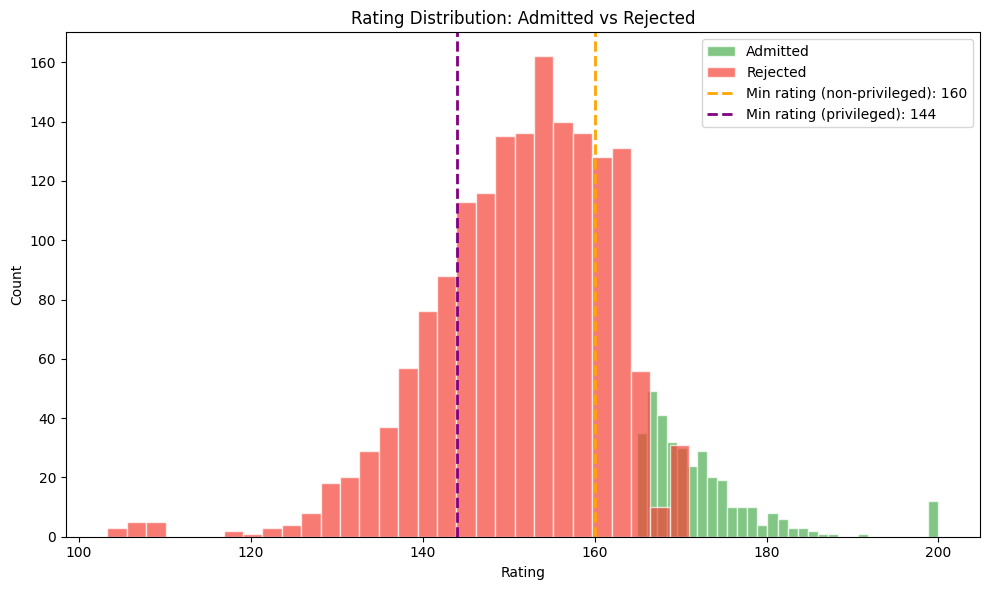

In [132]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df[df['admitted'] == 1]['rating'], bins=30, alpha=0.7,
        color='#4CAF50', label='Admitted', edgecolor='white')
ax.hist(df[df['admitted'] == 0]['rating'], bins=30, alpha=0.7,
        color='#F44336', label='Rejected', edgecolor='white')
ax.set_title('Rating Distribution: Admitted vs Rejected')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.axvline(x=160, color='orange', linestyle='--', linewidth=2,
           label='Min rating (non-privileged): 160')
ax.axvline(x=144, color='purple', linestyle='--', linewidth=2,
           label='Min rating (privileged): 144')
ax.legend()

plt.tight_layout()
plt.show()

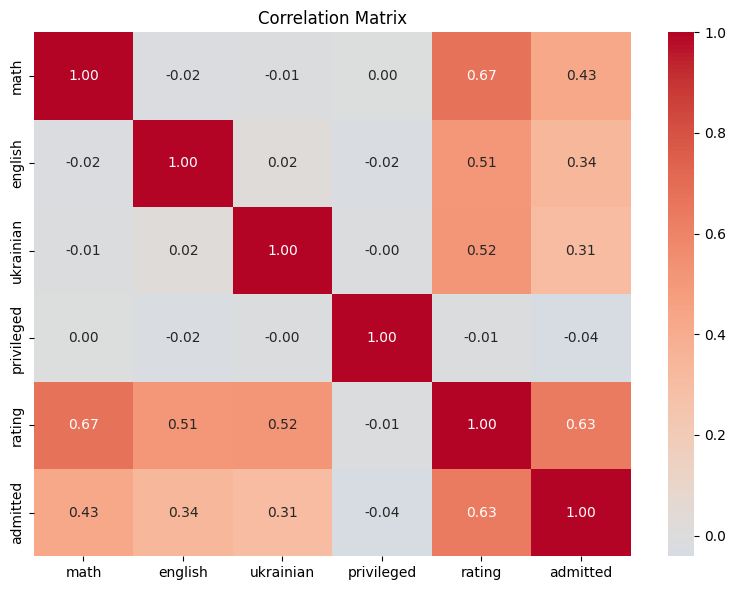

In [133]:
fig, ax = plt.subplots(figsize=(8, 6))

correlation = df[['math', 'english', 'ukrainian', 'privileged',
                   'rating', 'admitted']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [134]:
features = ['math', 'english', 'ukrainian', 'privileged']
target = 'admitted'

X = df[features].values
y = df[target].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {features}")

Features shape: (2000, 4)
Target shape: (2000,)
Feature columns: ['math', 'english', 'ukrainian', 'privileged']


In [135]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(f"  Min: {X.min(axis=0)}")
print(f"  Max: {X.max(axis=0)}")
print(f"\nAfter scaling:")
print(f"  Min: {X_scaled.min(axis=0)}")
print(f"  Max: {X_scaled.max(axis=0)}")

Before scaling:
  Min: [100 100 100   0]
  Max: [200 200 200   1]

After scaling:
  Min: [0. 0. 0. 0.]
  Max: [1. 1. 1. 1.]


In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(f"  Admitted: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"  Rejected: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"\nTest class distribution:")
print(f"  Admitted: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.1f}%)")
print(f"  Rejected: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")

Training set: 1600 samples
Test set: 400 samples

Training class distribution:
  Admitted: 280 (17.5%)
  Rejected: 1320 (82.5%)

Test class distribution:
  Admitted: 70 (17.5%)
  Rejected: 330 (82.5%)


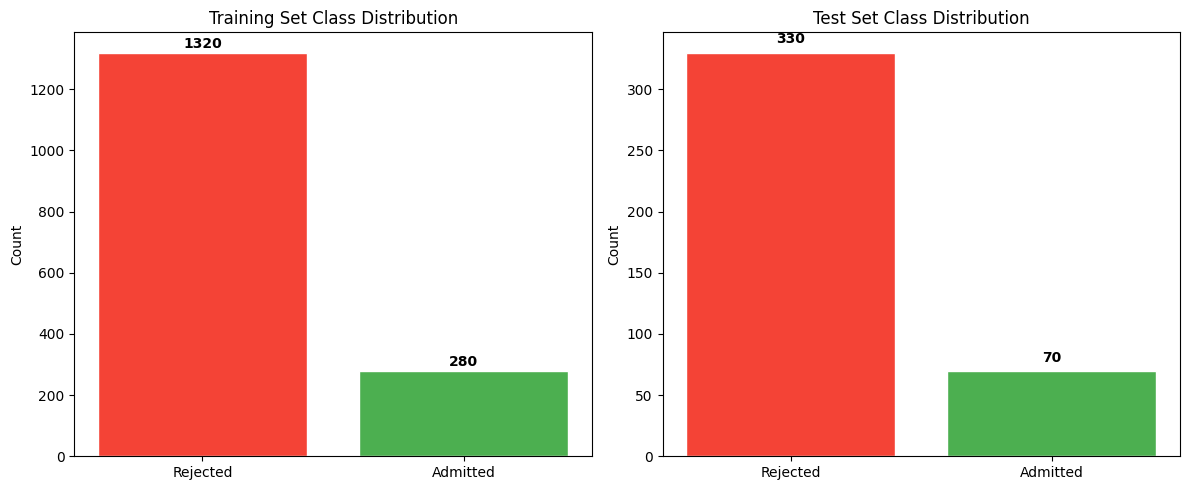

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in zip(axes, [y_train, y_test], ['Training Set', 'Test Set']):
    counts = [np.sum(data == 0), np.sum(data == 1)]
    bars = ax.bar(['Rejected', 'Admitted'], counts,
                  color=['#F44336', '#4CAF50'], edgecolor='white')
    ax.set_title(f'{title} Class Distribution')
    ax.set_ylabel('Count')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                f'{count}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Neural Network Models

In [138]:
def build_model(architecture, optimizer='adam', input_dim=4):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for units, activation in architecture:
        model.add(layers.Dense(units, activation=activation))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def train_model(model, X_train, y_train, X_test, y_test,
                epochs=100, batch_size=32, verbose=0):
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=verbose
    )
    training_time = time.time() - start_time
    return history, training_time

def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

model_results = {}

### Model 1: Minimal Network (1 hidden layer, 8 neurons)

In [139]:
tf.random.set_seed(42)

model1_arch = [(8, 'sigmoid')]
model1 = build_model(model1_arch, optimizer='adam')
model1.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

In [140]:
history1, time1 = train_model(model1, X_train, y_train, X_test, y_test,
                               epochs=100, batch_size=32)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)
print(f"Model 1 - Test Loss: {loss1:.4f}, Test Accuracy: {acc1:.4f}")
print(f"Training time: {time1:.2f}s")

model_results['Model 1 (8-sigmoid)'] = {
    'accuracy': acc1, 'loss': loss1, 'time': time1,
    'params': model1.count_params()
}

Model 1 - Test Loss: 0.2448, Test Accuracy: 0.8675
Training time: 12.95s


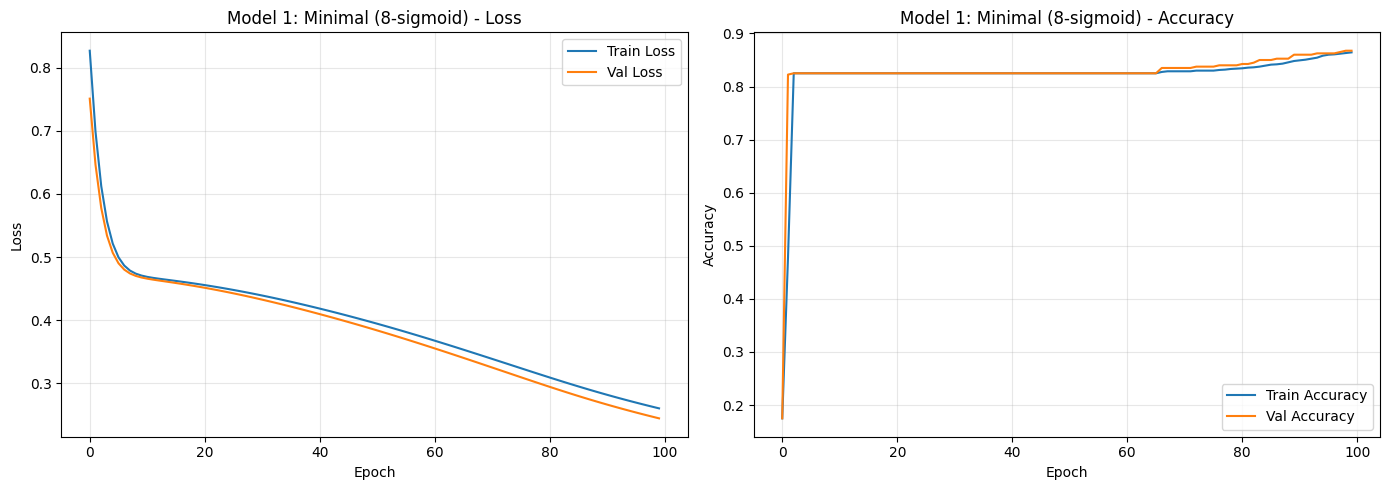

In [141]:
plot_training_history(history1, 'Model 1: Minimal (8-sigmoid)')

### Model 2: Medium Network (2 hidden layers, 16-8 neurons)

In [142]:
tf.random.set_seed(42)

model2_arch = [(16, 'relu'), (8, 'relu')]
model2 = build_model(model2_arch, optimizer='adam')
model2.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_74 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [143]:
history2, time2 = train_model(model2, X_train, y_train, X_test, y_test,
                               epochs=100, batch_size=32)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)
print(f"Model 2 - Test Loss: {loss2:.4f}, Test Accuracy: {acc2:.4f}")
print(f"Training time: {time2:.2f}s")

model_results['Model 2 (16-8-relu)'] = {
    'accuracy': acc2, 'loss': loss2, 'time': time2,
    'params': model2.count_params()
}

Model 2 - Test Loss: 0.0400, Test Accuracy: 0.9950
Training time: 12.79s


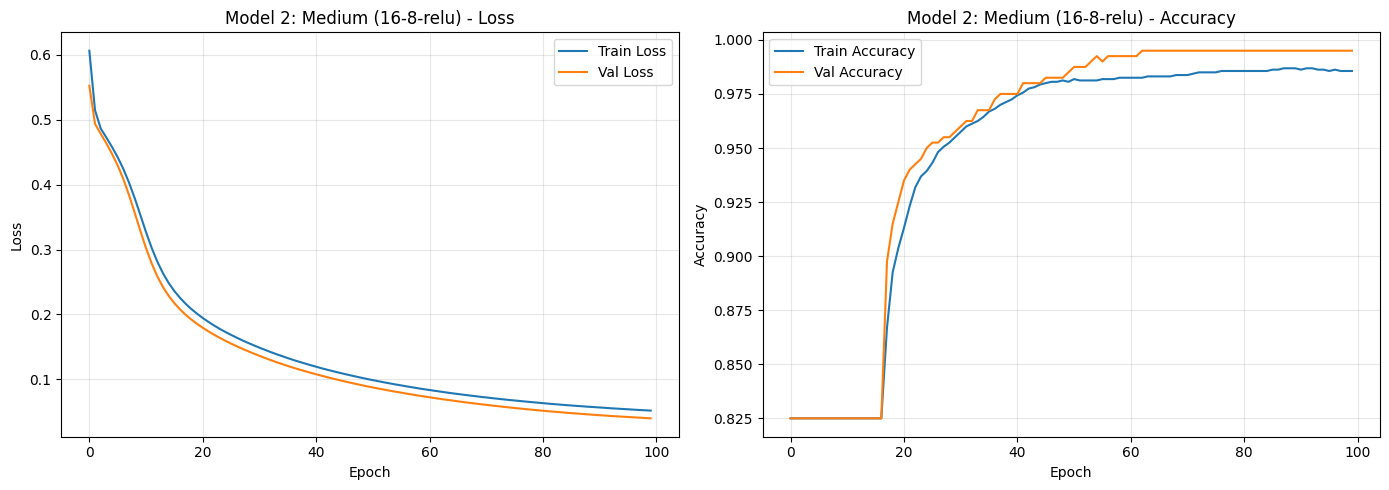

In [144]:
plot_training_history(history2, 'Model 2: Medium (16-8-relu)')

### Model 3: Extended Network (3 hidden layers, 32-16-8 neurons + Dropout)

In [145]:
tf.random.set_seed(42)

model3 = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_77 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [146]:
history3, time3 = train_model(model3, X_train, y_train, X_test, y_test,
                               epochs=100, batch_size=32)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)
print(f"Model 3 - Test Loss: {loss3:.4f}, Test Accuracy: {acc3:.4f}")
print(f"Training time: {time3:.2f}s")

model_results['Model 3 (32-16-8-relu-dropout)'] = {
    'accuracy': acc3, 'loss': loss3, 'time': time3,
    'params': model3.count_params()
}

Model 3 - Test Loss: 0.0279, Test Accuracy: 0.9975
Training time: 14.71s


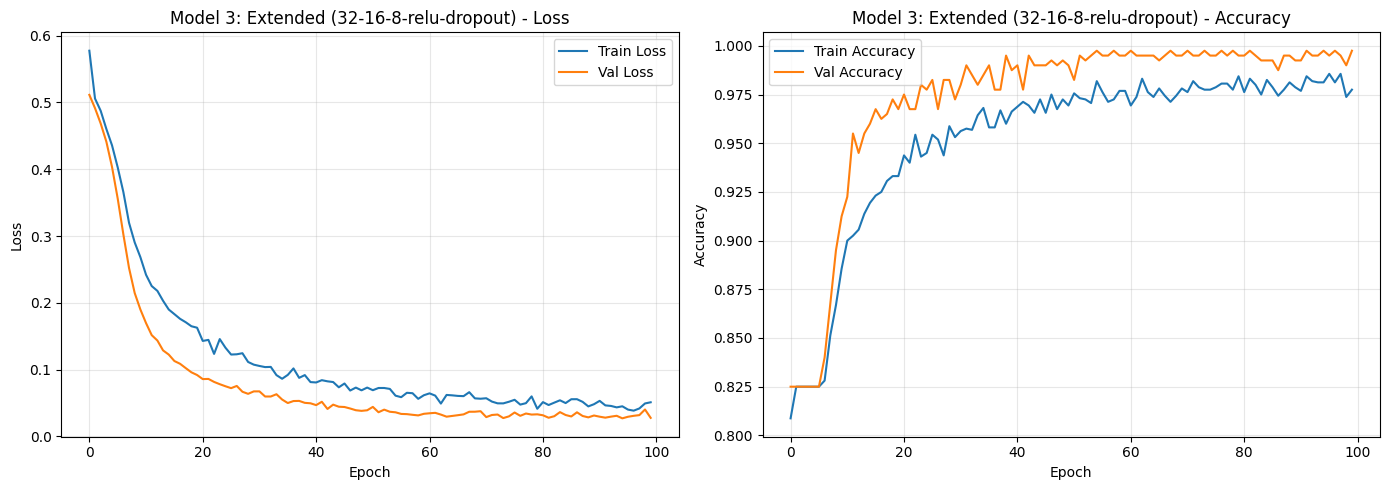

In [147]:
plot_training_history(history3, 'Model 3: Extended (32-16-8-relu-dropout)')

### Architecture Comparison

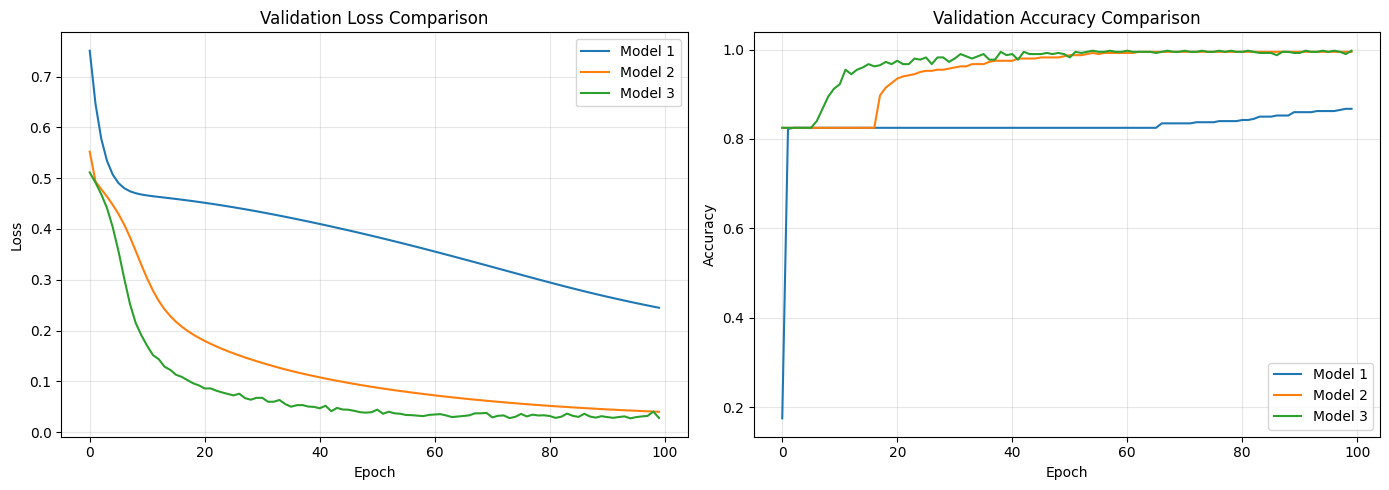

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for h, name in [(history1, 'Model 1'), (history2, 'Model 2'), (history3, 'Model 3')]:
    axes[0].plot(h.history['val_loss'], label=name)
    axes[1].plot(h.history['val_accuracy'], label=name)

axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [149]:
arch_comparison = pd.DataFrame(model_results).T
arch_comparison = arch_comparison.round(4)
print("Architecture Comparison:")
arch_comparison

Architecture Comparison:


,accuracy,loss,time,params
Model 1 (8-sigmoid),0.8675,0.2448,12.9534,49.0
Model 2 (16-8-relu),0.9950,0.0400,12.7888,225.0
Model 3 (32-16-8-relu-dropout),0.9975,0.0279,14.7086,833.0


## 5. Optimizer Comparison

In [150]:
optimizers = {
    'SGD': 'sgd',
    'Adagrad': 'adagrad',
    'Adadelta': 'adadelta',
    'RMSProp': 'rmsprop',
    'Adam': 'adam'
}

best_architecture = [(16, 'relu'), (8, 'relu')]

optimizer_histories = {}
optimizer_results = {}

for name, opt in optimizers.items():
    print(f"\nTraining with {name}...")
    tf.random.set_seed(42)

    model = build_model(best_architecture, optimizer=opt)
    history, train_time = train_model(model, X_train, y_train, X_test, y_test,
                                      epochs=100, batch_size=32)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"  {name} - Accuracy: {acc:.4f}, Loss: {loss:.4f}, Time: {train_time:.2f}s")

    optimizer_histories[name] = history
    optimizer_results[name] = {
        'accuracy': acc,
        'loss': loss,
        'time': train_time,
        'final_train_acc': history.history['accuracy'][-1],
        'final_val_acc': history.history['val_accuracy'][-1]
    }

    if name == 'Adam':
        best_model = model

print("\nAll optimizers trained!")


Training with SGD...
  SGD - Accuracy: 0.9575, Loss: 0.1409, Time: 12.55s

Training with Adagrad...
  Adagrad - Accuracy: 0.8250, Loss: 0.5256, Time: 12.59s

Training with Adadelta...
  Adadelta - Accuracy: 0.8150, Loss: 0.6232, Time: 13.03s

Training with RMSProp...
  RMSProp - Accuracy: 0.9950, Loss: 0.0379, Time: 12.48s

Training with Adam...
  Adam - Accuracy: 0.9950, Loss: 0.0501, Time: 13.16s

All optimizers trained!


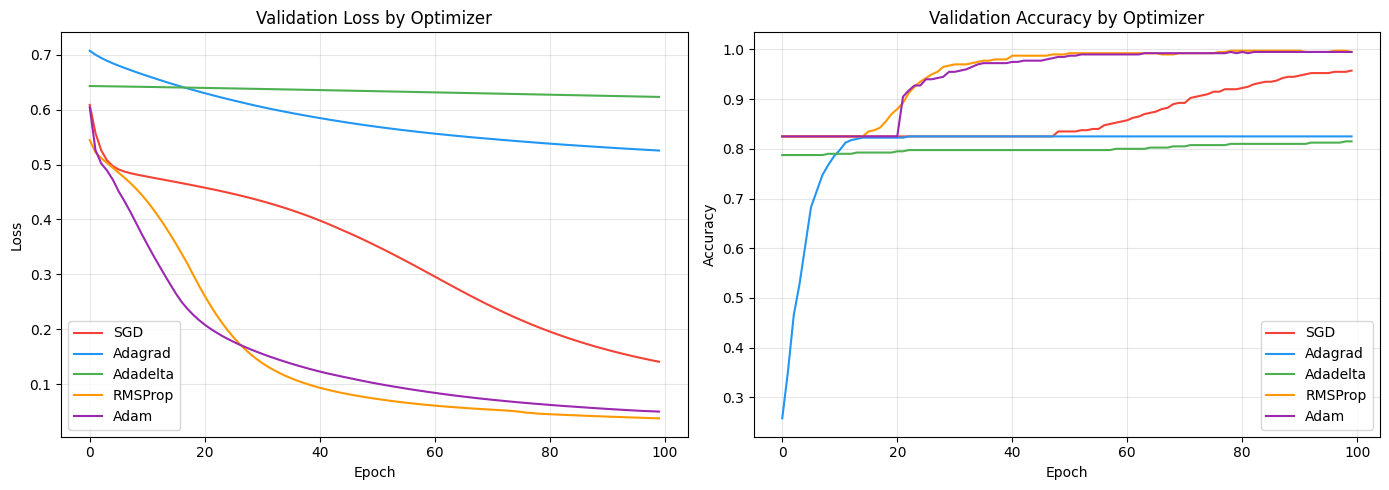

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#F44336', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
for (name, h), color in zip(optimizer_histories.items(), colors):
    axes[0].plot(h.history['val_loss'], label=name, color=color)
    axes[1].plot(h.history['val_accuracy'], label=name, color=color)

axes[0].set_title('Validation Loss by Optimizer')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy by Optimizer')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [152]:
opt_df = pd.DataFrame(optimizer_results).T
opt_df = opt_df.round(4)
opt_df.index.name = 'Optimizer'
print("Optimizer Comparison:")
opt_df

Optimizer Comparison:


,accuracy,loss,time,final_train_acc,final_val_acc
Optimizer,,,,,
SGD,0.9575,0.1409,12.5486,0.9394,0.9575
Adagrad,0.8250,0.5256,12.5913,0.8250,0.8250
Adadelta,0.8150,0.6232,13.0296,0.8144,0.8150
RMSProp,0.9950,0.0379,12.4781,0.9856,0.9950
Adam,0.9950,0.0501,13.1608,0.9837,0.9950


## 6. Model Evaluation

In [153]:
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Admitted']))

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Classification Report:
              precision    recall  f1-score   support

    Rejected       0.99      1.00      1.00       330
    Admitted       1.00      0.97      0.99        70

    accuracy                           0.99       400
   macro avg       1.00      0.99      0.99       400
weighted avg       1.00      0.99      0.99       400

Accuracy:  0.9950
Precision: 1.0000
Recall:    0.9714
F1-Score:  0.9855


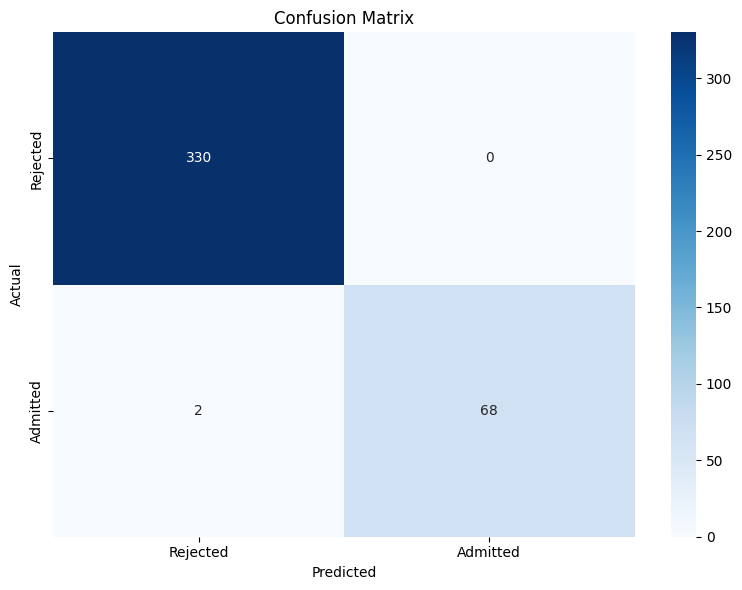

True Negatives (correctly rejected): 330
False Positives (wrongly admitted): 0
False Negatives (wrongly rejected): 2
True Positives (correctly admitted): 68


In [154]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Admitted'],
            yticklabels=['Rejected', 'Admitted'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly rejected): {tn}")
print(f"False Positives (wrongly admitted): {fp}")
print(f"False Negatives (wrongly rejected): {fn}")
print(f"True Positives (correctly admitted): {tp}")

### Error Analysis

In [155]:
X_test_original = scaler.inverse_transform(X_test)
test_analysis = pd.DataFrame(X_test_original, columns=features)
test_analysis['actual'] = y_test
test_analysis['predicted'] = (y_pred_prob > 0.5).astype(int) if 'y_pred_prob' in locals() and 'y_pred' not in locals() else y_pred
test_analysis['rating'] = 0.4 * test_analysis['math'] + 0.3 * test_analysis['english'] + 0.3 * test_analysis['ukrainian']

false_positives = test_analysis[(test_analysis['actual'] == 0) & (test_analysis['predicted'] == 1)]
false_negatives = test_analysis[(test_analysis['actual'] == 1) & (test_analysis['predicted'] == 0)]

print(f"False Positives (wrongly admitted): {len(false_positives)}")
if len(false_positives) > 0:
    print(false_positives[['math', 'english', 'ukrainian', 'privileged', 'rating']].to_string())

print(f"\nFalse Negatives (wrongly rejected): {len(false_negatives)}")
if len(false_negatives) > 0:
    print(false_negatives[['math', 'english', 'ukrainian', 'privileged', 'rating']].to_string())

False Positives (wrongly admitted): 0

False Negatives (wrongly rejected): 2
      math  english  ukrainian  privileged  rating
100  146.0    182.0      176.0         0.0   165.8
149  184.0    126.0      188.0         1.0   167.8


### Admission Count Deviation

In [156]:
X_current_scaled = scaler.transform(df_current[features].values)
y_current_pred_prob = best_model.predict(X_current_scaled)
y_current_pred = (y_current_pred_prob > 0.5).astype(int).flatten()

predicted_admitted_current = y_current_pred.sum()
actual_admitted_current = df_current['admitted'].sum()
deviation_current = predicted_admitted_current - actual_admitted_current

print(f"Current Year Expected admitted: {actual_admitted_current}")
print(f"Current Year Model predicted admitted: {predicted_admitted_current}")
print(f"Deviation: {deviation_current} ({deviation_current/actual_admitted_current*100:+.1f}%)")
print(f"\nDeviation is {'critical' if abs(deviation_current) > 35 else 'acceptable'}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step
Current Year Expected admitted: 350
Current Year Model predicted admitted: 332
Deviation: -18 (-5.1%)

Deviation is acceptable


## 7. Anomalous Data Testing

In [157]:
anomalous_cases = pd.DataFrame([
    {'case': 'All max scores', 'math': 200, 'english': 200, 'ukrainian': 200, 'privileged': 0,
     'expected': 'admitted'},
    {'case': 'All min scores', 'math': 100, 'english': 100, 'ukrainian': 100, 'privileged': 0,
     'expected': 'rejected'},
    {'case': 'High math+eng, low ukr', 'math': 200, 'english': 200, 'ukrainian': 100, 'privileged': 0,
     'expected': 'rejected (ukr<120)'},
    {'case': 'Privileged at boundary', 'math': 120, 'english': 120, 'ukrainian': 120, 'privileged': 1,
     'expected': 'rejected (rating=120<144)'},
    {'case': 'Privileged good scores', 'math': 160, 'english': 160, 'ukrainian': 160, 'privileged': 1,
     'expected': 'admitted'},
    {'case': 'No priv, math<140', 'math': 130, 'english': 200, 'ukrainian': 200, 'privileged': 0,
     'expected': 'rejected (math<140)'},
    {'case': 'Rating boundary 160', 'math': 170, 'english': 155, 'ukrainian': 155, 'privileged': 0,
     'expected': 'admitted (rating=161)'},
    {'case': 'Just below 160 rating', 'math': 165, 'english': 153, 'ukrainian': 153, 'privileged': 0,
     'expected': 'rejected (rating=157.8)'},
    {'case': 'High scores, low eng', 'math': 195, 'english': 105, 'ukrainian': 190, 'privileged': 0,
     'expected': 'rejected (eng<120)'},
    {'case': 'All 150 no priv', 'math': 150, 'english': 150, 'ukrainian': 150, 'privileged': 0,
     'expected': 'rejected (math<140 and rating=150<160)'},
])

anomalous_cases['rating'] = (0.4 * anomalous_cases['math'] +
                              0.3 * anomalous_cases['english'] +
                              0.3 * anomalous_cases['ukrainian'])
anomalous_cases

,case,math,english,ukrainian,privileged,expected,rating
0,All max scores,200,200,200,0,admitted,200.0
1,All min scores,100,100,100,0,rejected,100.0
2,"High math+eng, low ukr",200,200,100,0,rejected (ukr<120),170.0
3,Privileged at boundary,120,120,120,1,rejected (rating=120<144),120.0
4,Privileged good scores,160,160,160,1,admitted,160.0
5,"No priv, math<140",130,200,200,0,rejected (math<140),172.0
6,Rating boundary 160,170,155,155,0,admitted (rating=161),161.0
7,Just below 160 rating,165,153,153,0,rejected (rating=157.8),157.8
8,"High scores, low eng",195,105,190,0,rejected (eng<120),166.5
9,All 150 no priv,150,150,150,0,rejected (math<140 and rating=150<160),150.0


In [158]:
X_anomalous = anomalous_cases[features].values
X_anomalous_scaled = scaler.transform(X_anomalous)

predictions = best_model.predict(X_anomalous_scaled)
pred_labels = (predictions > 0.5).astype(int).flatten()

anomalous_cases['prediction_prob'] = predictions.flatten().round(4)
anomalous_cases['predicted'] = ['admitted' if p == 1 else 'rejected' for p in pred_labels]

result_cols = ['case', 'math', 'english', 'ukrainian', 'privileged',
               'rating', 'expected', 'predicted', 'prediction_prob']
anomalous_cases[result_cols]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


,case,math,english,ukrainian,privileged,rating,expected,predicted,prediction_prob
0,All max scores,200,200,200,0,200.0,admitted,admitted,0.8930
1,All min scores,100,100,100,0,100.0,rejected,rejected,0.0000
2,"High math+eng, low ukr",200,200,100,0,170.0,rejected (ukr<120),rejected,0.0337
3,Privileged at boundary,120,120,120,1,120.0,rejected (rating=120<144),rejected,0.0000
4,Privileged good scores,160,160,160,1,160.0,admitted,rejected,0.0013
5,"No priv, math<140",130,200,200,0,172.0,rejected (math<140),admitted,0.8930
6,Rating boundary 160,170,155,155,0,161.0,admitted (rating=161),rejected,0.0075
7,Just below 160 rating,165,153,153,0,157.8,rejected (rating=157.8),rejected,0.0001
8,"High scores, low eng",195,105,190,0,166.5,rejected (eng<120),rejected,0.0353
9,All 150 no priv,150,150,150,0,150.0,rejected (math<140 and rating=150<160),rejected,0.0000


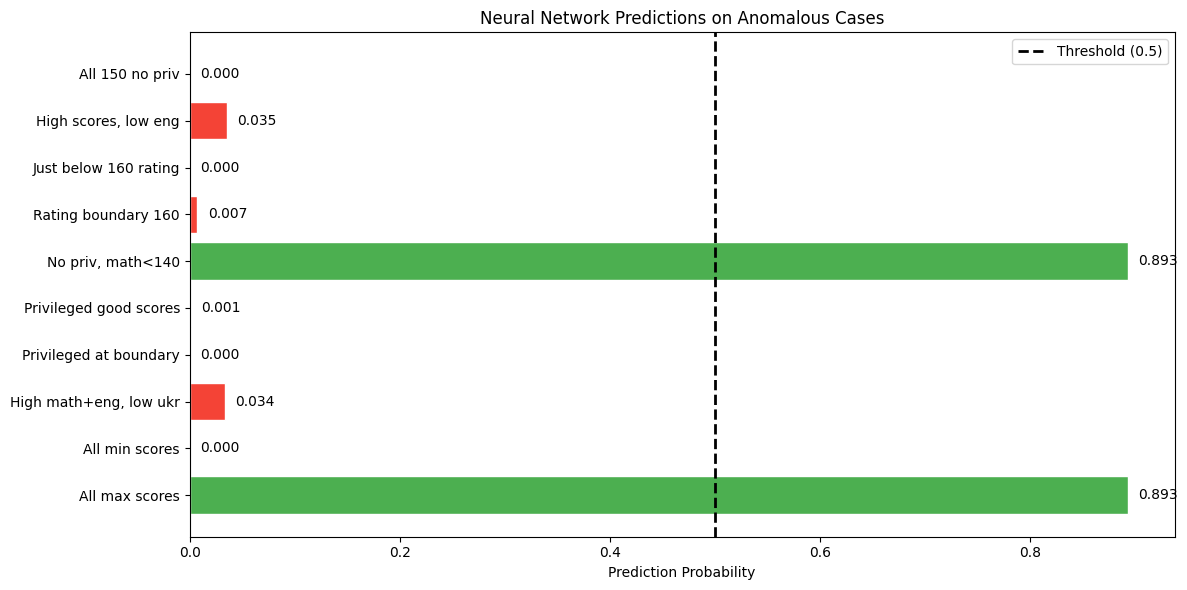

In [159]:
fig, ax = plt.subplots(figsize=(12, 6))

cases = anomalous_cases['case']
probs = anomalous_cases['prediction_prob']
colors = ['#4CAF50' if p > 0.5 else '#F44336' for p in probs]

bars = ax.barh(cases, probs, color=colors, edgecolor='white')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax.set_xlabel('Prediction Probability')
ax.set_title('Neural Network Predictions on Anomalous Cases')
ax.legend()

for bar, prob in zip(bars, probs):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{prob:.3f}', va='center')

plt.tight_layout()
plt.show()

## 8. Final Results and Excel Export

In [160]:
df_current_pred = df_current.copy()

X_final_scaled = scaler.transform(df_current_pred[features].values)
df_current_pred['nn_prediction'] = (best_model.predict(X_final_scaled) > 0.5).astype(int).flatten()

admitted_list = df_current_pred[df_current_pred['nn_prediction'] == 1].sort_values('rating', ascending=False)
admitted_list = admitted_list[['id', 'math', 'english', 'ukrainian', 'privileged', 'rating', 'admitted']]

print(f"Total admitted by neural network (Current Year): {len(admitted_list)}")
print(f"Privileged admitted: {admitted_list[admitted_list['privileged'] == 1].shape[0]}")
print(f"Non-privileged admitted: {admitted_list[admitted_list['privileged'] == 0].shape[0]}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step
Total admitted by neural network (Current Year): 332
Privileged admitted: 35
Non-privileged admitted: 297


In [161]:
admitted_list.to_excel('data/admitted_students.xlsx', index=False)
print("Admitted students list saved to data/admitted_students.xlsx")

Admitted students list saved to data/admitted_students.xlsx


In [162]:
print("Top-10 admitted students:")
admitted_list.head(10)

Top-10 admitted students:


,id,math,english,ukrainian,privileged,rating,admitted
1994,1995,200,200,200,0,200.0,1
1859,1860,200,200,200,0,200.0,1
1834,1835,200,200,200,0,200.0,1
295,296,200,200,200,0,200.0,1
1737,1738,200,200,200,0,200.0,1
1779,1780,200,200,200,1,200.0,1
1517,1518,200,200,200,0,200.0,1
555,556,200,200,200,0,200.0,1
1463,1464,200,200,200,0,200.0,1
1045,1046,200,200,200,0,200.0,1


In [163]:
print("Bottom-10 admitted students (closest to cutoff):")
admitted_list.tail(10)

Bottom-10 admitted students (closest to cutoff):


,id,math,english,ukrainian,privileged,rating,admitted
61,62,170,167,158,0,165.5,1
919,920,173,162,159,0,165.5,1
1333,1334,167,176,153,0,165.5,1
246,247,167,183,146,0,165.5,1
380,381,170,163,162,0,165.5,1
1244,1245,160,161,177,0,165.4,1
1619,1620,162,175,160,0,165.3,1
369,370,159,172,167,0,165.3,1
1803,1804,159,157,182,0,165.3,1
1068,1069,180,158,152,0,165.0,1


### Final Visualizations

In [164]:
print("Best model architecture:")
best_model.summary()

Best model architecture:


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_93 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677 (2.65 KB)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 452 (1.77 KB)

In [165]:
print("FINAL SUMMARY")

print("\n--- Architecture Comparison ---")
arch_df = pd.DataFrame(model_results).T
print(arch_df.round(4).to_string())

print("\n--- Optimizer Comparison ---")
opt_df_final = pd.DataFrame(optimizer_results).T
print(opt_df_final.round(4).to_string())

print(f"\n--- Final Test Metrics (Historical Data Test Split) ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"False Positives: {fp}, False Negatives: {fn}")

print(f"\n--- Current Year Admission Results (Production Inference) ---")
print(f"Goal Quota Expected: {actual_admitted_current}")
print(f"Neural Network Predicted: {predicted_admitted_current}")
print(f"Deviation: {deviation_current} ({(deviation_current/actual_admitted_current)*100:+.1f}%)")

FINAL SUMMARY

--- Architecture Comparison ---
                                accuracy    loss     time  params
Model 1 (8-sigmoid)               0.8675  0.2448  12.9534    49.0
Model 2 (16-8-relu)               0.9950  0.0400  12.7888   225.0
Model 3 (32-16-8-relu-dropout)    0.9975  0.0279  14.7086   833.0

--- Optimizer Comparison ---
          accuracy    loss     time  final_train_acc  final_val_acc
SGD         0.9575  0.1409  12.5486           0.9394         0.9575
Adagrad     0.8250  0.5256  12.5913           0.8250         0.8250
Adadelta    0.8150  0.6232  13.0296           0.8144         0.8150
RMSProp     0.9950  0.0379  12.4781           0.9856         0.9950
Adam        0.9950  0.0501  13.1608           0.9837         0.9950

--- Final Test Metrics (Historical Data Test Split) ---
Accuracy:  0.9950
Precision: 1.0000
Recall:    0.9714
F1-Score:  0.9855
False Positives: 0, False Negatives: 2

--- Current Year Admission Results (Production Inference) ---
Goal Quota Expected: